<a href="https://colab.research.google.com/github/Dipu1764/Trending-YouTube-Video-Internship-Project/blob/DATA/Trending_YouTube_Video_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Essential Libraries**

In [16]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# **Download Dataset with Kaggle**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube-new")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/youtube-new


# **Define Paths for CSV and JSON Files**

In [3]:
# Path to downloaded dataset
data_path = path  # this will be set from kagglehub output

# Define search paths
csv_path = os.path.join(data_path, "*.csv")
json_path = os.path.join(data_path, "*.json")


# **Load JSON Category Mappings**

In [4]:
category_mappings = {}

for json_file in glob.glob(json_path):
    region = os.path.basename(json_file).split("_")[0]   # e.g., "US" from "US_category_id.json"
    with open(json_file, "r") as f:
        categories = json.load(f)
    cat_dict = {item["id"]: item["snippet"]["title"] for item in categories["items"]}
    category_mappings[region] = cat_dict


# **Load and Merge CSV Files**

In [5]:
youtube_list = []

for csv_file in glob.glob(csv_path):
    region = os.path.basename(csv_file).replace("videos.csv", "")  # e.g., "US" from "USvideos.csv"
    temp = pd.read_csv(csv_file, encoding="ISO-8859-1")
    temp["region"] = region
    temp["category_id"] = temp["category_id"].astype(str)
    if region in category_mappings:
        temp["category_name"] = temp["category_id"].map(category_mappings[region])
    else:
        temp["category_name"] = None
    youtube_list.append(temp)

# Combine everything
youtube = pd.concat(youtube_list, ignore_index=True)

print("✅ Combined dataset created:", youtube.shape)
youtube.head()


✅ Combined dataset created: (375942, 18)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,region,category_name
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...,GB,Howto & Style
1,3s1rvMFUweQ,17.14.11,Taylor Swift: â¦Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs â¦Ready f...,GB,Entertainment
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,GB,Music
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...,GB,Sports
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...,GB,News & Politics


# **Save the Combined Dataset**

In [6]:
youtube.to_csv("youtube_combined_raw.csv", index=False)
print("File saved: youtube_combined_raw.csv")


File saved: youtube_combined_raw.csv


In [7]:
youtube = pd.read_csv("/content/youtube_combined_raw.csv")
youtube.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,region,category_name
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...,GB,Howto & Style
1,3s1rvMFUweQ,17.14.11,Taylor Swift: â¦Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs â¦Ready f...,GB,Entertainment
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,GB,Music
3,PUTEiSjKwJU,17.14.11,Goals from Salford City vs Class of 92 and Fri...,Salford City Football Club,17,2017-11-13T02:30:38.000Z,"Salford City FC|""Salford City""|""Salford""|""Clas...",27833,193,12,37,https://i.ytimg.com/vi/PUTEiSjKwJU/default.jpg,False,False,False,Salford drew 4-4 against the Class of 92 and F...,GB,Sports
4,rHwDegptbI4,17.14.11,Dashcam captures truck's near miss with child ...,Cute Girl Videos,25,2017-11-13T01:45:13.000Z,[none],9815,30,2,30,https://i.ytimg.com/vi/rHwDegptbI4/default.jpg,False,False,False,Dashcam captures truck's near miss with child ...,GB,News & Politics


In [8]:
youtube.shape

(375942, 18)

In [9]:
youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375942 entries, 0 to 375941
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                375942 non-null  object
 1   trending_date           375942 non-null  object
 2   title                   375942 non-null  object
 3   channel_title           375942 non-null  object
 4   category_id             375942 non-null  int64 
 5   publish_time            375942 non-null  object
 6   tags                    375942 non-null  object
 7   views                   375942 non-null  int64 
 8   likes                   375942 non-null  int64 
 9   dislikes                375942 non-null  int64 
 10  comment_count           375942 non-null  int64 
 11  thumbnail_link          375942 non-null  object
 12  comments_disabled       375942 non-null  bool  
 13  ratings_disabled        375942 non-null  bool  
 14  video_error_or_removed  375942 non-n

In [10]:
youtube.describe()

,category_id,views,likes,dislikes,comment_count
count,375942.000000,3.759420e+05,3.759420e+05,3.759420e+05,3.759420e+05
mean,20.232302,1.326568e+06,3.788431e+04,2.126107e+03,4.253775e+03
std,7.132413,7.098568e+06,1.654131e+05,2.248437e+04,2.545876e+04
min,1.000000,1.170000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,4.697800e+04,6.690000e+02,4.100000e+01,1.090000e+02
50%,23.000000,1.773705e+05,3.446000e+03,1.790000e+02,5.110000e+02
75%,24.000000,6.476792e+05,1.747650e+04,7.490000e+02,2.011000e+03
max,44.000000,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06


In [11]:
youtube.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'region', 'category_name'],
      dtype='object')

In [12]:
youtube.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [13]:
youtube.duplicated().sum()

np.int64(12570)

# **Data Cleaning & Preprocessing**

In [15]:
# --- CLEANING PIPELINE ---

# Convert trending_date
youtube["trending_date"] = pd.to_datetime(youtube["trending_date"], format="%y.%d.%m", errors="coerce")

# Convert publish_time & extract date + hour
youtube["publish_time"] = pd.to_datetime(youtube["publish_time"], errors="coerce")
youtube["publish_date"] = youtube["publish_time"].dt.date
youtube["publish_hour"] = youtube["publish_time"].dt.hour

# Clean tags column
youtube["tags"] = youtube["tags"].replace("[none]", "", regex=True)

# Convert boolean-like columns to proper booleans
bool_cols = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]
for col in bool_cols:
    youtube[col] = youtube[col].astype(bool)

# Remove duplicates
youtube.drop_duplicates(subset=["video_id", "region", "trending_date"], inplace=True)

# Handle missing values
youtube["description"] = youtube["description"].fillna("")
youtube["category_name"] = youtube["category_name"].fillna("Unknown")

# Save cleaned dataset
youtube.to_csv("youtube_clean.csv", index=False)

print("✅ Data Cleaning Complete! Saved as youtube_clean.csv")
print("Final Shape:", youtube.shape)


✅ Data Cleaning Complete! Saved as youtube_clean.csv
Final Shape: (269855, 20)


# **Exploratory Data Analysis (EDA)**

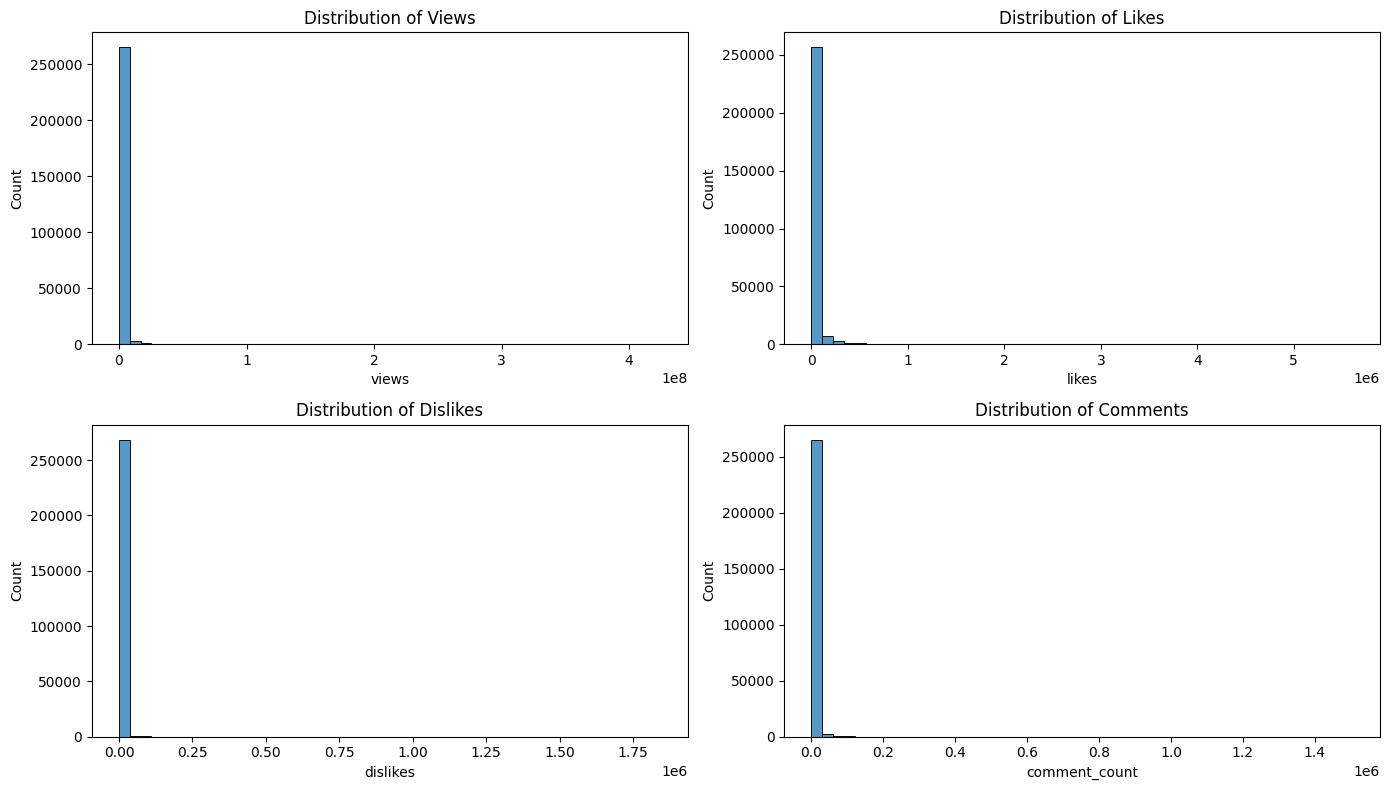

In [17]:
# Distribution of views, likes, dislikes, comments
fig, axes = plt.subplots(2, 2, figsize=(14,8))
sns.histplot(youtube["views"], bins=50, ax=axes[0,0])
axes[0,0].set_title("Distribution of Views")

sns.histplot(youtube["likes"], bins=50, ax=axes[0,1])
axes[0,1].set_title("Distribution of Likes")

sns.histplot(youtube["dislikes"], bins=50, ax=axes[1,0])
axes[1,0].set_title("Distribution of Dislikes")

sns.histplot(youtube["comment_count"], bins=50, ax=axes[1,1])
axes[1,1].set_title("Distribution of Comments")

plt.tight_layout()
plt.show()

/tmp/ipython-input-1886013275.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


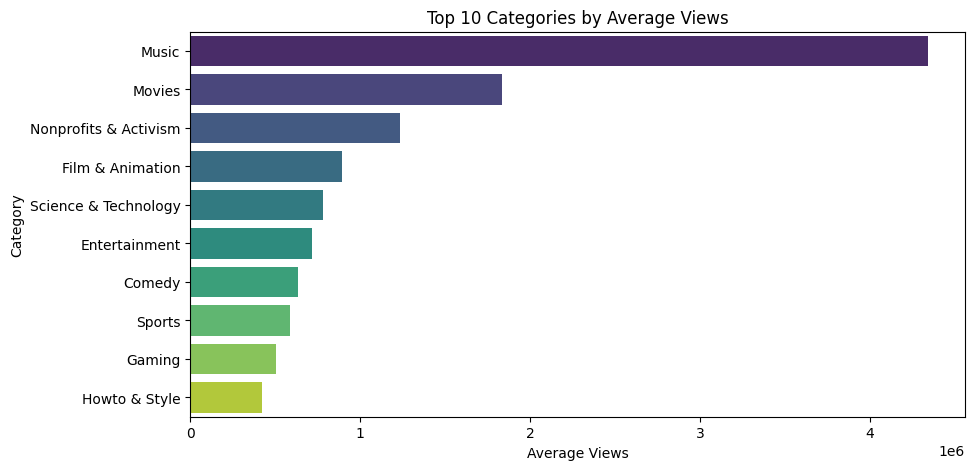

In [18]:
# Top 10 categories by average views
top_categories = youtube.groupby("category_name")["views"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 10 Categories by Average Views")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.show()

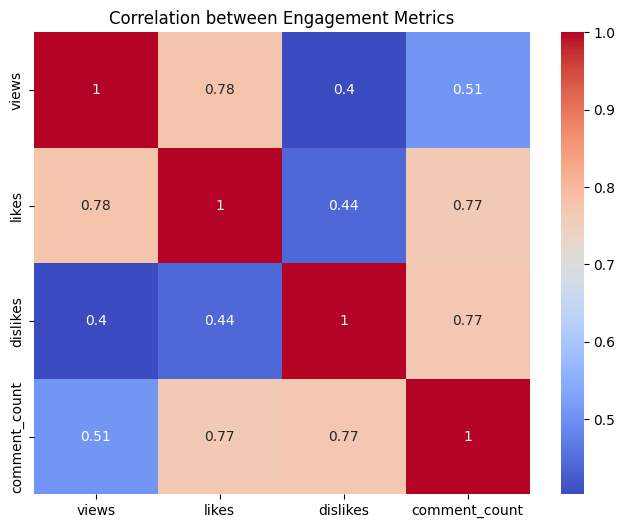

In [19]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(youtube[["views","likes","dislikes","comment_count"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Engagement Metrics")
plt.show()

# **Sentiment Analysis (Titles & Tags)**

In [21]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon (only once)
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [23]:
# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Function to get sentiment category
def get_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"


In [24]:
# 1. Sentiment for Titles
youtube["title_sentiment_score"] = youtube["title"].astype(str).apply(lambda x: sia.polarity_scores(x)["compound"])
youtube["title_sentiment"] = youtube["title_sentiment_score"].apply(get_sentiment)

# 2. Sentiment for Tags
youtube["tags_sentiment_score"] = youtube["tags"].astype(str).apply(lambda x: sia.polarity_scores(x)["compound"])
youtube["tags_sentiment"] = youtube["tags_sentiment_score"].apply(get_sentiment)

# Check distribution
print("Title Sentiment Counts:\n", youtube["title_sentiment"].value_counts())
print("\nTags Sentiment Counts:\n", youtube["tags_sentiment"].value_counts())

Title Sentiment Counts:
 title_sentiment
Neutral     207354
Positive     33207
Negative     29294
Name: count, dtype: int64

Tags Sentiment Counts:
 tags_sentiment
Neutral     252621
Negative      8768
Positive      8466
Name: count, dtype: int64


# **Visualization of Sentiments**

/tmp/ipython-input-858780218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="title_sentiment", data=youtube, palette="Set2", order=["Positive","Neutral","Negative"])


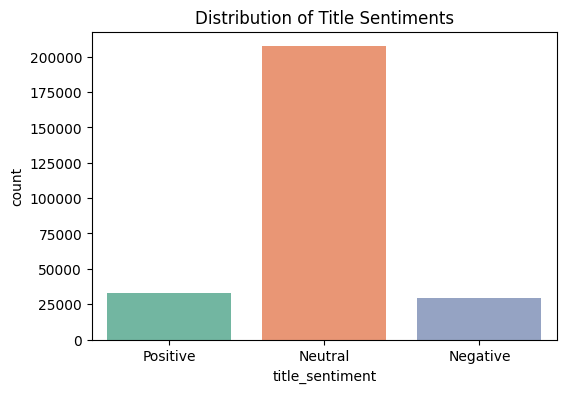

In [26]:
# Title Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="title_sentiment", data=youtube, palette="Set2", order=["Positive","Neutral","Negative"])
plt.title("Distribution of Title Sentiments")
plt.show()

/tmp/ipython-input-2800556280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="tags_sentiment", data=youtube, palette="Set1", order=["Positive","Neutral","Negative"])


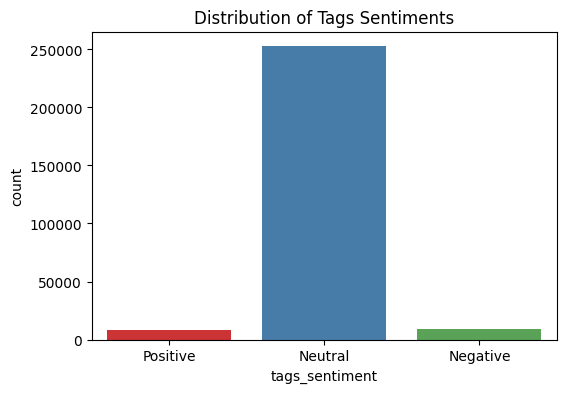

In [27]:
# Tags Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="tags_sentiment", data=youtube, palette="Set1", order=["Positive","Neutral","Negative"])
plt.title("Distribution of Tags Sentiments")
plt.show()


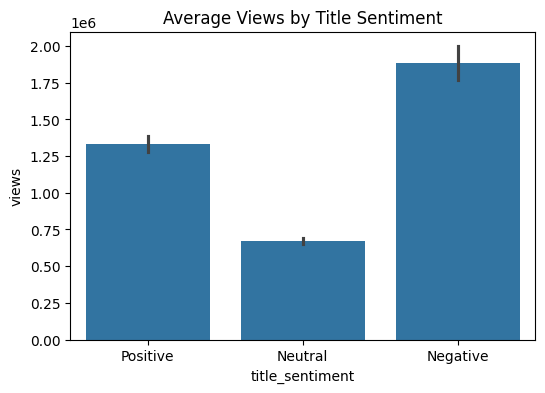

In [28]:
# Avg views by sentiment
plt.figure(figsize=(6,4))
sns.barplot(x="title_sentiment", y="views", data=youtube, estimator=lambda x: sum(x)/len(x), order=["Positive","Neutral","Negative"])
plt.title("Average Views by Title Sentiment")
plt.show()

# **Setup SQLite and Load Data**

In [29]:
import sqlite3

# 1. Connect to SQLite (creates file if not exists)
conn = sqlite3.connect("youtube.db")

# 2. Write dataframe to SQL table
youtube.to_sql("youtube_trending", conn, if_exists="replace", index=False)

print("✅ youtube_clean.csv loaded into SQLite DB")


✅ youtube_clean.csv loaded into SQLite DB


**Top categories by average views**

In [33]:
# Execute SQL query and load into pandas DataFrame
query = """
SELECT category_name, AVG(views) AS avg_views
FROM youtube_trending
GROUP BY category_name
ORDER BY avg_views DESC
LIMIT 10;
"""
pd.read_sql(query, conn)


,category_name,avg_views
0,Music,4.344158e+06
1,Movies,1.834639e+06
2,Nonprofits & Activism,1.237799e+06
3,Film & Animation,8.908429e+05
4,Science & Technology,7.843808e+05
5,Entertainment,7.166739e+05
6,Comedy,6.334296e+05
7,Sports,5.857241e+05
8,Gaming,5.030855e+05
9,Howto & Style,4.204987e+05


**Longest-trending videos by region**

In [34]:
query = """
SELECT video_id, title, region, COUNT(DISTINCT trending_date) AS trending_days
FROM youtube_trending
GROUP BY video_id, region
ORDER BY trending_days DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,video_id,title,region,trending_days
0,#NAME?,ÐÐ¾Ð²Ð¸Ð½ÐºÐ¸ Ð¸Ð½ÑÐµÑÐ½ÐµÑ Ð¼Ð°Ð³Ð°Ð·Ð¸Ð½...,RU,75
1,#NAME?,à°¸âà°®à°à°¤ à°à°à°âà°¤âà°¡à°¿ | Sam...,IN,73
2,#NAME?,Â¿QuÃ© versiÃ³n prefieres? Roast Yourself vs. ...,MX,73
3,#NAME?,SNL9 ê¸ìì²´í¹ê°5 ã ã ì¤ê°ì ìí¼ì...,KR,65
4,#NAME?,Love Like Flower | Flower Ever After | Season ...,JP,39
5,2z3EUY1aXdY,Justin Timberlakeâs FULL Pepsi Super Bowl LI...,GB,20
6,BhIEIO0vaBE,To Our Daughter,GB,20
7,NooW_RbfdWI,Jurassic World: Fallen Kingdom - Official Trai...,GB,20
8,baj6llvgpWA,Justin Timberlake - Man of the Woods (Official...,GB,19
9,tEnCoocmPQM,Halsey - Sorry,GB,19


**Engagement metrics by region**

In [35]:
query = """
SELECT region,
       AVG(views) AS avg_views,
       AVG(likes) AS avg_likes,
       AVG(dislikes) AS avg_dislikes,
       AVG(comment_count) AS avg_comments
FROM youtube_trending
GROUP BY region
ORDER BY avg_views DESC;
"""
pd.read_sql(query, conn)


,region,avg_views,avg_likes,avg_dislikes,avg_comments
0,GB,5.462412e+06,127447.120642,7060.076835,12549.863360
1,US,2.130433e+06,68515.336572,3678.253283,7979.184690
2,CA,8.580892e+05,29646.607135,1505.408763,3923.530818
3,IN,7.491958e+05,19041.186669,1303.312563,2028.343631
4,DE,4.742895e+05,17021.419595,1083.266770,2225.160284
5,KR,3.548675e+05,10227.646975,533.025636,1669.473405
6,FR,3.319834e+05,13150.600886,637.357447,1442.660566
7,MX,2.670606e+05,12580.721543,586.023992,1671.217010
8,JP,2.123312e+05,6743.275653,280.476925,965.489285
9,RU,1.943913e+05,10160.686678,1114.606442,1460.512429
